# 🌍 Global Trade Data Story
### Using the WITS API via `world_trade_data`

**Narrative arc:**
1. **The Big Picture** — What does global trade look like by sector?
2. **Who Trades What** — Trade balance per country per sector (geo heatmap)
3. **Winners & Losers** — Which sectors are growing or shrinking per country?
4. **Market Concentration** — Are markets getting more or less competitive?
5. **Denmark in Context** — Where does Denmark sit in the global picture?

---
**API note:** `reporter='all'` + `partner='wld'` is allowed. `reporter='all'` + `partner='all'` is blocked by the WITS API.

## 0. Setup & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import world_trade_data as wits
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 8)
pd.set_option('display.max_columns', 10)

In [2]:
# ── Visual style (matplotlib) ──────────────────────────────────────────────
BACKGROUND = '#0f1117'
PANEL      = '#1a1d27'
GRID       = '#2a2d3a'
TEXT       = '#e8eaf0'
ACCENT_EXP = '#4fc3f7'
ACCENT_IMP = '#ef5350'
ACCENT_NEU = '#b0bec5'

plt.rcParams.update({
    'figure.facecolor': BACKGROUND, 'axes.facecolor':  PANEL,
    'axes.edgecolor':   GRID,       'axes.labelcolor': TEXT,
    'axes.titlecolor':  TEXT,       'xtick.color':     ACCENT_NEU,
    'ytick.color':      ACCENT_NEU, 'grid.color':      GRID,
    'grid.linewidth':   0.6,        'text.color':      TEXT,
    'font.family':      'monospace','legend.facecolor': PANEL,
    'legend.edgecolor': GRID,       'legend.labelcolor': TEXT,
})

# ── Sector codes (HS sector groups) ───────────────────────────────────────
SECTOR_CODES = [
    '01-05_Animal', '06-15_Vegetable', '16-24_FoodProd',
    '25-26_Minerals', '27-27_Fuels', '28-38_Chemicals',
    '39-40_PlastiRub', '41-43_HidesSkin', '44-49_Wood',
    '50-63_TextCloth', '64-67_Footwear', '68-71_StoneGlas',
    '72-83_Metals', '84-85_MachElec', '86-89_Transport',
    '90-99_Miscellan'
]

# Short display labels (same order as SECTOR_CODES)
SECTOR_LABELS = {
    '01-05_Animal':   'Animal',
    '06-15_Vegetable':'Vegetable',
    '16-24_FoodProd': 'Food',
    '25-26_Minerals': 'Minerals',
    '27-27_Fuels':    'Fuels',
    '28-38_Chemicals':'Chemicals',
    '39-40_PlastiRub':'Plastics',
    '41-43_HidesSkin':'Hides',
    '44-49_Wood':     'Wood',
    '50-63_TextCloth':'Textiles',
    '64-67_Footwear': 'Footwear',
    '68-71_StoneGlas':'Stone/Glass',
    '72-83_Metals':   'Metals',
    '84-85_MachElec': 'Machinery',
    '86-89_Transport':'Transport',
    '90-99_Miscellan':'Misc'
}

LATEST_YEAR = '2022'
REPORTER_FOCUS = 'dnk'  # Denmark

print('Config ready.')

Config ready.


## 1. Data Loading Helpers

In [3]:
def load_sector_shares(indicator: str, reporter: str, year: str,
                       sector_codes: list) -> list:
    """Load one DataFrame per sector; returns list of raw MultiIndex DataFrames."""
    dfs = []
    for code in sector_codes:
        try:
            df = wits.get_indicator(
                indicator=indicator, reporter=reporter,
                year=year, product=code
            )
            df['sector_code'] = code
            dfs.append(df)
            print(f'  ✓ {code}')
        except Exception as e:
            print(f'  ✗ {code}: {e}')
    return dfs


def extract_series(df_list: list, share_label: str,
                   freq='Annual', reporter='Denmark',
                   partner='World') -> pd.DataFrame:
    """
    Flatten a list of MultiIndex DataFrames into a wide DataFrame.
    Index = Year (int), Columns = product names.
    Works for both single-reporter (time series) and
    multi-reporter (cross-section) data.
    """
    series_dict = {}
    for df in df_list:
        product_name = df.index.get_level_values('ProductCode')[0]
        flat = df.reset_index()
        mask = (
            (flat['Freq']      == freq)     &
            (flat['Reporter']  == reporter) &
            (flat['Partner']   == partner)  &
            (flat['Indicator'] == share_label)
        )
        filtered = flat.loc[mask].copy()
        if filtered.empty:
            print(f'  ⚠  no data for {product_name}')
            continue
        s = filtered.set_index('Year')['Value']
        s.index = s.index.astype(int)
        s.name = product_name
        series_dict[product_name] = s
    return pd.DataFrame(series_dict).sort_index()


def extract_cross_section(df_list: list, share_label: str,
                          year: int, partner='World') -> pd.DataFrame:
    """
    For multi-reporter data: returns a DataFrame
    with index=Reporter ISO3, columns=sector labels, values=share.
    """
    frames = []
    for df in df_list:
        sector_code = df['sector_code'].iloc[0]
        flat = df.reset_index()
        mask = (
            (flat['Freq']      == 'Annual') &
            (flat['Partner']   == partner)  &
            (flat['Indicator'] == share_label) &
            (flat['Year'].astype(int) == year)
        )
        filtered = flat.loc[mask, ['Reporter', 'Value']].copy()
        filtered.columns = ['Reporter', sector_code]
        filtered = filtered.set_index('Reporter')
        frames.append(filtered)
    if not frames:
        return pd.DataFrame()
    result = pd.concat(frames, axis=1)
    result.columns = [SECTOR_LABELS.get(c, c) for c in result.columns]
    return result


print('Helpers defined.')

Helpers defined.


---
## Chapter 1 · The Big Picture
### Global trade composition by sector — what does the world export and import?

In [4]:
# Load global export & import shares (reporter='wld' = world aggregate)
print('Loading world export shares...')
wld_export_raw = load_sector_shares(
    'XPRT-PRDCT-SHR', reporter='wld', year='all', sector_codes=SECTOR_CODES
)

print('\nLoading world import shares...')
wld_import_raw = load_sector_shares(
    'MPRT-PRDCT-SHR', reporter='wld', year='all', sector_codes=SECTOR_CODES
)

Loading world export shares...


  ✓ 01-05_Animal
  ✓ 06-15_Vegetable
  ✓ 16-24_FoodProd
  ✓ 25-26_Minerals
  ✓ 27-27_Fuels
  ✓ 28-38_Chemicals
  ✓ 39-40_PlastiRub
  ✓ 41-43_HidesSkin
  ✓ 44-49_Wood
  ✓ 50-63_TextCloth
  ✓ 64-67_Footwear
  ✓ 68-71_StoneGlas
  ✓ 72-83_Metals
  ✓ 84-85_MachElec
  ✓ 86-89_Transport
  ✓ 90-99_Miscellan

Loading world import shares...
  ✓ 01-05_Animal
  ✓ 06-15_Vegetable
  ✓ 16-24_FoodProd
  ✓ 25-26_Minerals
  ✓ 27-27_Fuels
  ✓ 28-38_Chemicals
  ✓ 39-40_PlastiRub
  ✓ 41-43_HidesSkin
  ✓ 44-49_Wood
  ✓ 50-63_TextCloth
  ✓ 64-67_Footwear
  ✓ 68-71_StoneGlas
  ✓ 72-83_Metals
  ✓ 84-85_MachElec
  ✓ 86-89_Transport
  ✓ 90-99_Miscellan


In [5]:
wld_export_df = extract_series(
    wld_export_raw, 'Export Product Share (%)',
    reporter='World', partner='World'
)
wld_import_df = extract_series(
    wld_import_raw, 'Import Product Share (%)',
    reporter='World', partner='World'
)

# Rename columns to short labels
wld_export_df.columns = [SECTOR_LABELS.get(c, c) for c in wld_export_df.columns]
wld_import_df.columns = [SECTOR_LABELS.get(c, c) for c in wld_import_df.columns]

print(f'Shape: {wld_export_df.shape}  ({wld_export_df.shape[0]} years × {wld_export_df.shape[1]} sectors)')
wld_export_df.tail(3)

Shape: (36, 16)  (36 years × 16 sectors)


,Animal,Vegetable,Food Products,Minerals,Fuels,...,Stone and Glass,Metals,Mach and Elec,Transportation,Miscellaneous
Year,,,,,,,,,,,
2021,1.8952,3.4854,3.4112,1.8558,10.3585,...,4.6071,7.1973,26.2804,9.3291,8.7020
2022,1.8448,3.4838,3.3315,1.4821,13.9849,...,4.4541,6.8818,25.5091,8.7142,7.8349
2023,1.8759,3.4399,3.6790,1.5525,11.4489,...,4.5876,6.5611,26.3151,10.4935,8.3615


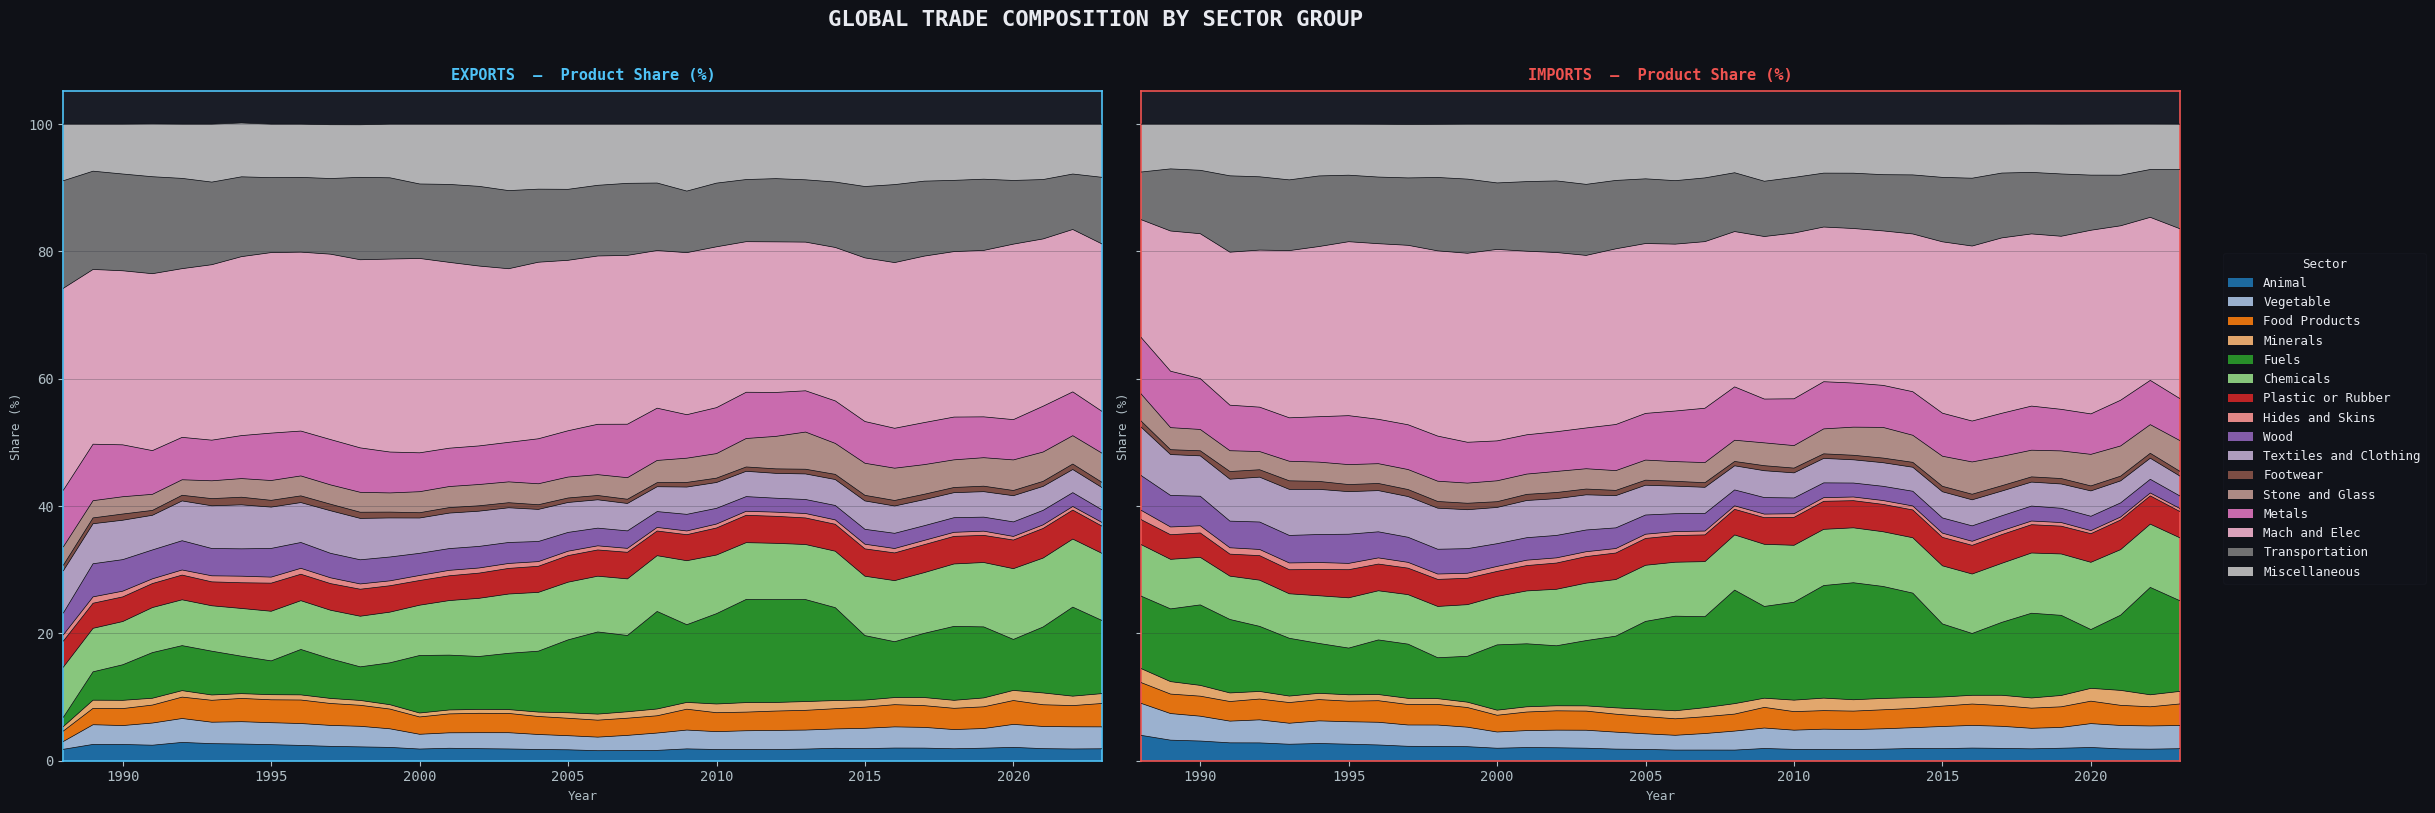

In [6]:
# ── 1A: Stacked area — global trade composition over time ──────────────────
palette = sns.color_palette('tab20', len(wld_export_df.columns))

fig, (ax_exp, ax_imp) = plt.subplots(1, 2, figsize=(22, 8), sharey=True)
fig.suptitle('GLOBAL TRADE COMPOSITION BY SECTOR GROUP',
             fontsize=16, fontweight='bold', color=TEXT, y=1.01)

for ax, df, title, edge in [
    (ax_exp, wld_export_df, 'EXPORTS  –  Product Share (%)', ACCENT_EXP),
    (ax_imp, wld_import_df, 'IMPORTS  –  Product Share (%)', ACCENT_IMP),
]:
    years  = df.index.values
    values = [df[p].fillna(0).values for p in df.columns]
    ax.stackplot(years, values, labels=df.columns.tolist(),
                 colors=palette, alpha=0.88)
    cumulative = np.zeros(len(years))
    for v in values:
        cumulative += v
        ax.plot(years, cumulative, color=BACKGROUND, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=11, fontweight='bold', color=edge, pad=8)
    ax.set_xlabel('Year', fontsize=9, color=ACCENT_NEU)
    ax.set_ylabel('Share (%)', fontsize=9, color=ACCENT_NEU)
    ax.set_xlim(years.min(), years.max())
    ax.set_ylim(0)
    ax.grid(True, axis='y', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor(edge)
        spine.set_linewidth(1.2)

handles, labels = ax_exp.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5),
           fontsize=9, framealpha=0.15, title='Sector', title_fontsize=9)
plt.tight_layout()
plt.savefig('ch1_global_stacked.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

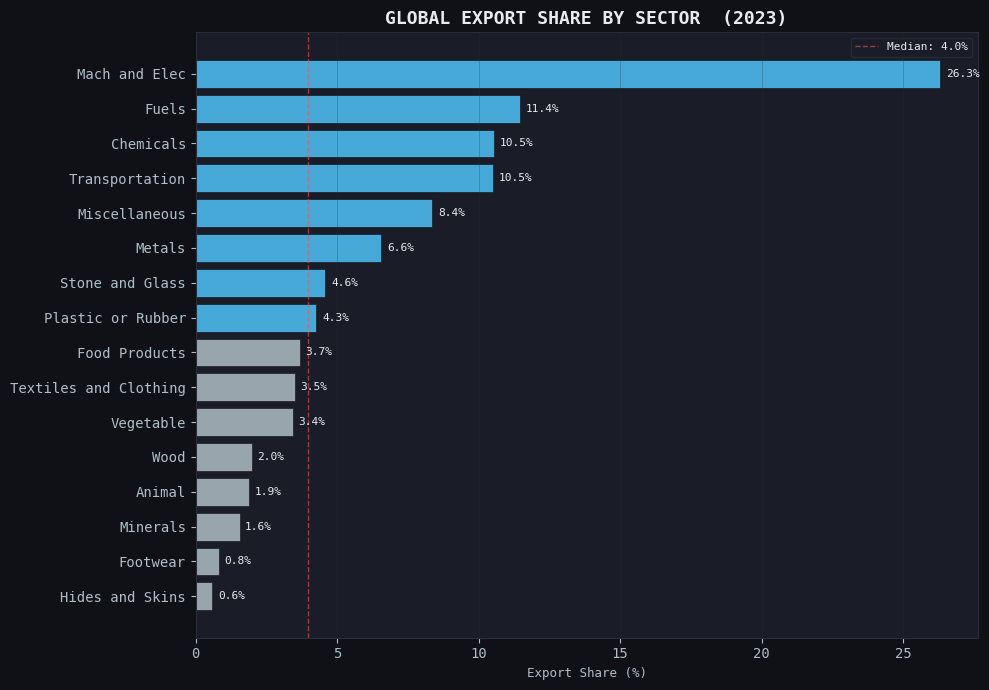

In [7]:
# ── 1B: Latest-year snapshot bar chart ────────────────────────────────────
latest = wld_export_df.iloc[-1].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(latest.index, latest.values,
               color=[ACCENT_EXP if v > latest.median() else ACCENT_NEU
                      for v in latest.values],
               alpha=0.85, edgecolor=BACKGROUND, linewidth=0.5)

for bar, val in zip(bars, latest.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=8, color=TEXT)

ax.set_title(f'GLOBAL EXPORT SHARE BY SECTOR  ({wld_export_df.index[-1]})',
             fontsize=13, fontweight='bold', color=TEXT)
ax.set_xlabel('Export Share (%)', fontsize=9, color=ACCENT_NEU)
ax.grid(True, axis='x', alpha=0.3)
ax.axvline(latest.median(), color=ACCENT_IMP, linewidth=1,
           linestyle='--', alpha=0.6, label=f'Median: {latest.median():.1f}%')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('ch1_sector_bar.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

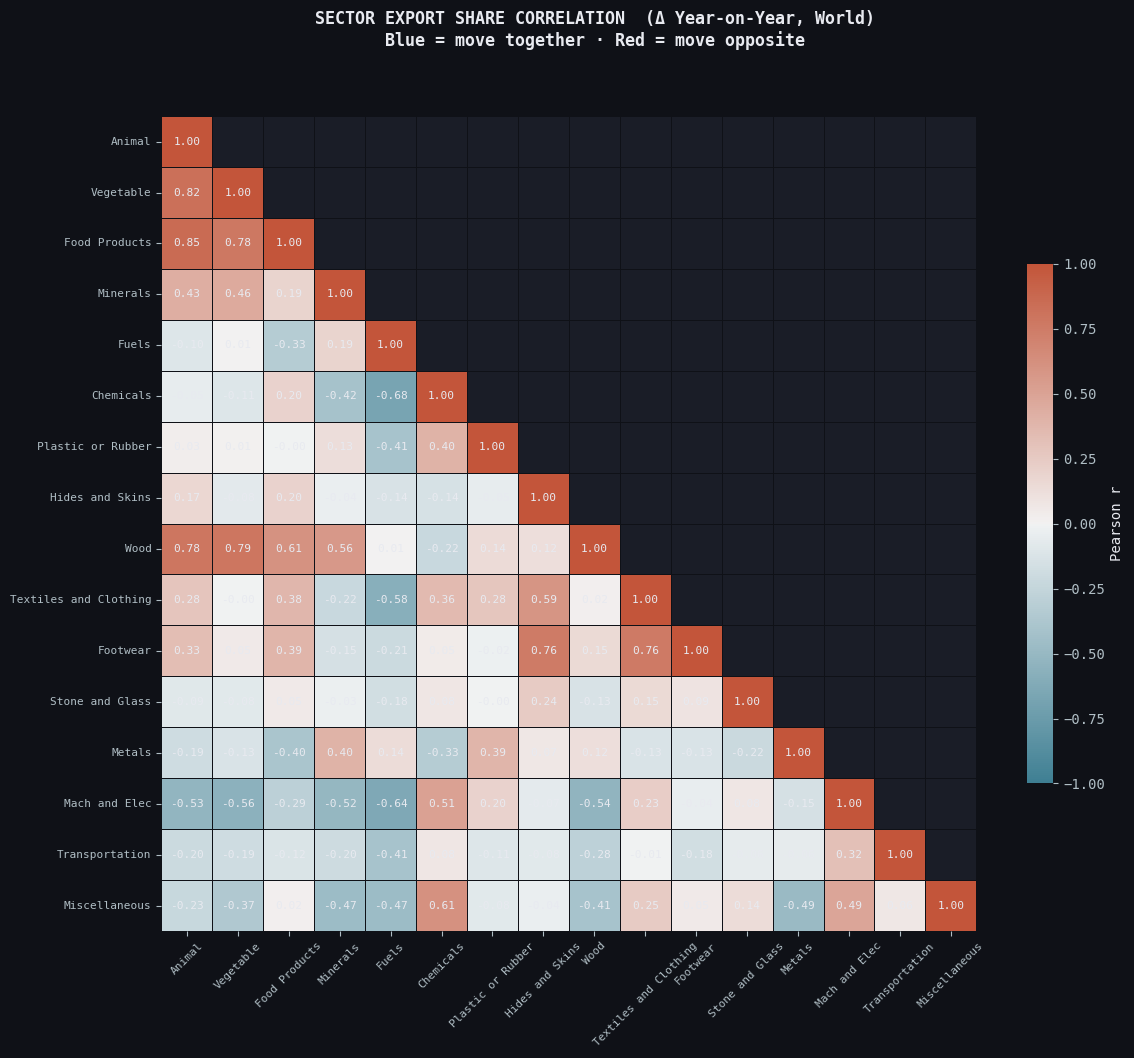

Most NEGATIVELY correlated sector pairs:
             Sector A  Sector B         r
            Chemicals     Fuels -0.679497
        Mach and Elec     Fuels -0.639912
Textiles and Clothing     Fuels -0.579935
        Mach and Elec Vegetable -0.557937
        Mach and Elec      Wood -0.538925

Most POSITIVELY correlated sector pairs:
     Sector A  Sector B        r
Food Products Vegetable 0.778659
         Wood    Animal 0.783616
         Wood Vegetable 0.786886
    Vegetable    Animal 0.822683
Food Products    Animal 0.854065


In [8]:
# ── 1C: Correlation matrix (first-differenced export shares) ──────────────
diff_corr = wld_export_df.diff().dropna().corr()

mask = np.triu(np.ones_like(diff_corr, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 20, as_cmap=True)

n = len(diff_corr)
fig, ax = plt.subplots(figsize=(max(10, n*0.75), max(9, n*0.65)))
fig.suptitle(
    'SECTOR EXPORT SHARE CORRELATION  (Δ Year-on-Year, World)\n'
    'Blue = move together · Red = move opposite',
    fontsize=12, fontweight='bold', color=TEXT, y=1.01
)

sns.heatmap(
    diff_corr, ax=ax, mask=mask, cmap=cmap,
    vmin=-1, vmax=1, center=0, square=True,
    annot=True, fmt='.2f', annot_kws={'size': 8, 'color': TEXT},
    linewidths=0.4, linecolor=BACKGROUND,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
)
ax.tick_params(axis='x', labelsize=8, rotation=45, colors=ACCENT_NEU)
ax.tick_params(axis='y', labelsize=8, rotation=0, colors=ACCENT_NEU)
diff_corr.columns[diff_corr.min() < -0.3]
plt.tight_layout()
plt.savefig('ch1_correlation.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

# Print most notable pairs
corr_pairs = (
    diff_corr.where(mask == False)
    .stack().reset_index()
    .rename(columns={'level_0':'Sector A','level_1':'Sector B', 0:'r'})
    .query('`Sector A` != `Sector B`')
    .sort_values('r')
)
print('Most NEGATIVELY correlated sector pairs:')
print(corr_pairs.head(5).to_string(index=False))
print('\nMost POSITIVELY correlated sector pairs:')
print(corr_pairs.tail(5).to_string(index=False))

---
## Chapter 2 · Who Trades What
### Trade balance per country per sector — interactive geo heatmap

In [9]:
# Load all-reporter export & import shares for the latest year
# (reporter='all' + partner='wld' is allowed by the API)
print('Loading all-reporter export shares...')
all_export_raw = load_sector_shares(
    'XPRT-PRDCT-SHR', reporter='all',
    year=LATEST_YEAR, sector_codes=SECTOR_CODES
)

print('\nLoading all-reporter import shares...')
all_import_raw = load_sector_shares(
    'MPRT-PRDCT-SHR', reporter='all',
    year=LATEST_YEAR, sector_codes=SECTOR_CODES
)

Loading all-reporter export shares...
  ✓ 01-05_Animal
  ✓ 06-15_Vegetable
  ✓ 16-24_FoodProd
  ✓ 25-26_Minerals
  ✓ 27-27_Fuels
  ✓ 28-38_Chemicals
  ✓ 39-40_PlastiRub
  ✓ 41-43_HidesSkin
  ✓ 44-49_Wood
  ✓ 50-63_TextCloth
  ✓ 64-67_Footwear
  ✓ 68-71_StoneGlas
  ✓ 72-83_Metals
  ✓ 84-85_MachElec
  ✓ 86-89_Transport
  ✓ 90-99_Miscellan

Loading all-reporter import shares...
  ✓ 01-05_Animal
  ✓ 06-15_Vegetable
  ✓ 16-24_FoodProd
  ✓ 25-26_Minerals
  ✓ 27-27_Fuels
  ✓ 28-38_Chemicals
  ✓ 39-40_PlastiRub
  ✓ 41-43_HidesSkin
  ✓ 44-49_Wood
  ✓ 50-63_TextCloth
  ✓ 64-67_Footwear
  ✓ 68-71_StoneGlas
  ✓ 72-83_Metals
  ✓ 84-85_MachElec
  ✓ 86-89_Transport
  ✓ 90-99_Miscellan


In [10]:
# Build cross-section matrices: index=country name, columns=sector label
exp_cross = extract_cross_section(
    all_export_raw, 'Export Product Share (%)', year=int(LATEST_YEAR)
)
imp_cross = extract_cross_section(
    all_import_raw, 'Import Product Share (%)', year=int(LATEST_YEAR)
)

# Align and compute balance
common_countries = exp_cross.index.intersection(imp_cross.index)
common_sectors   = exp_cross.columns.intersection(imp_cross.columns)
balance_cross = (
    exp_cross.loc[common_countries, common_sectors] -
    imp_cross.loc[common_countries, common_sectors]
)

# Attach ISO3 codes for Plotly choropleth
countries_meta = wits.get_countries()
name_to_iso3 = (
    countries_meta
    .reset_index()
    .rename(columns={'iso3Code': 'iso3', 'name': 'country_name'})
    [['iso3', 'country_name']]
    .set_index('country_name')
)

balance_cross['iso3'] = balance_cross.index.map(
    lambda x: name_to_iso3.loc[x, 'iso3'] if x in name_to_iso3.index else None
)
balance_cross = balance_cross.dropna(subset=['iso3'])

print(f'Countries with data: {len(balance_cross)}')
balance_cross.head(3)

Countries with data: 163


,Animal,Vegetable,Food,Minerals,Fuels,...,Metals,Machinery,Transport,Misc,iso3
Reporter,,,,,,,,,,,
Aruba,-8.7129,-5.2344,47.8532,-0.8579,-6.7008,...,2.7110,-7.9589,-3.7036,-2.1698,ABW
Angola,-4.2292,-9.9160,-3.9078,0.0000,70.4170,...,-6.2176,-18.3483,-6.8872,-3.7835,AGO
Albania,-1.7715,-1.5139,-3.4819,4.3321,-0.3112,...,8.7639,-1.2447,-5.2058,-7.8356,ALB


In [11]:
# ── 2A: Interactive choropleth — sector slider ────────────────────────────
# Melt to long format for Plotly animation
bal_long = (
    balance_cross
    .reset_index()
    .rename(columns={'Reporter': 'Country'})   # ← was 'index', should be 'Reporter'
    .melt(id_vars=['Country', 'iso3'],
          var_name='Sector', value_name='Balance')
    .dropna(subset=['Balance'])
)

fig = px.choropleth(
    bal_long,
    locations='iso3',
    color='Balance',
    hover_name='Country',
    hover_data={'iso3': False, 'Balance': ':.2f'},
    animation_frame='Sector',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    range_color=[-30, 30],
    title=f'TRADE BALANCE BY SECTOR & COUNTRY  ({LATEST_YEAR})<br>'
          '<sup>Blue = net exporter · Red = net importer · Use slider to change sector</sup>',
    template='plotly_dark',
    width=1100,
    height=580,
)
fig.update_layout(
    coloraxis_colorbar=dict(title='Export − Import<br>share (pp)'),
    geo=dict(showframe=False, showcoastlines=True,
             coastlinecolor='rgba(200,200,200,0.3)'),
    font_family='monospace',
)
fig.show()

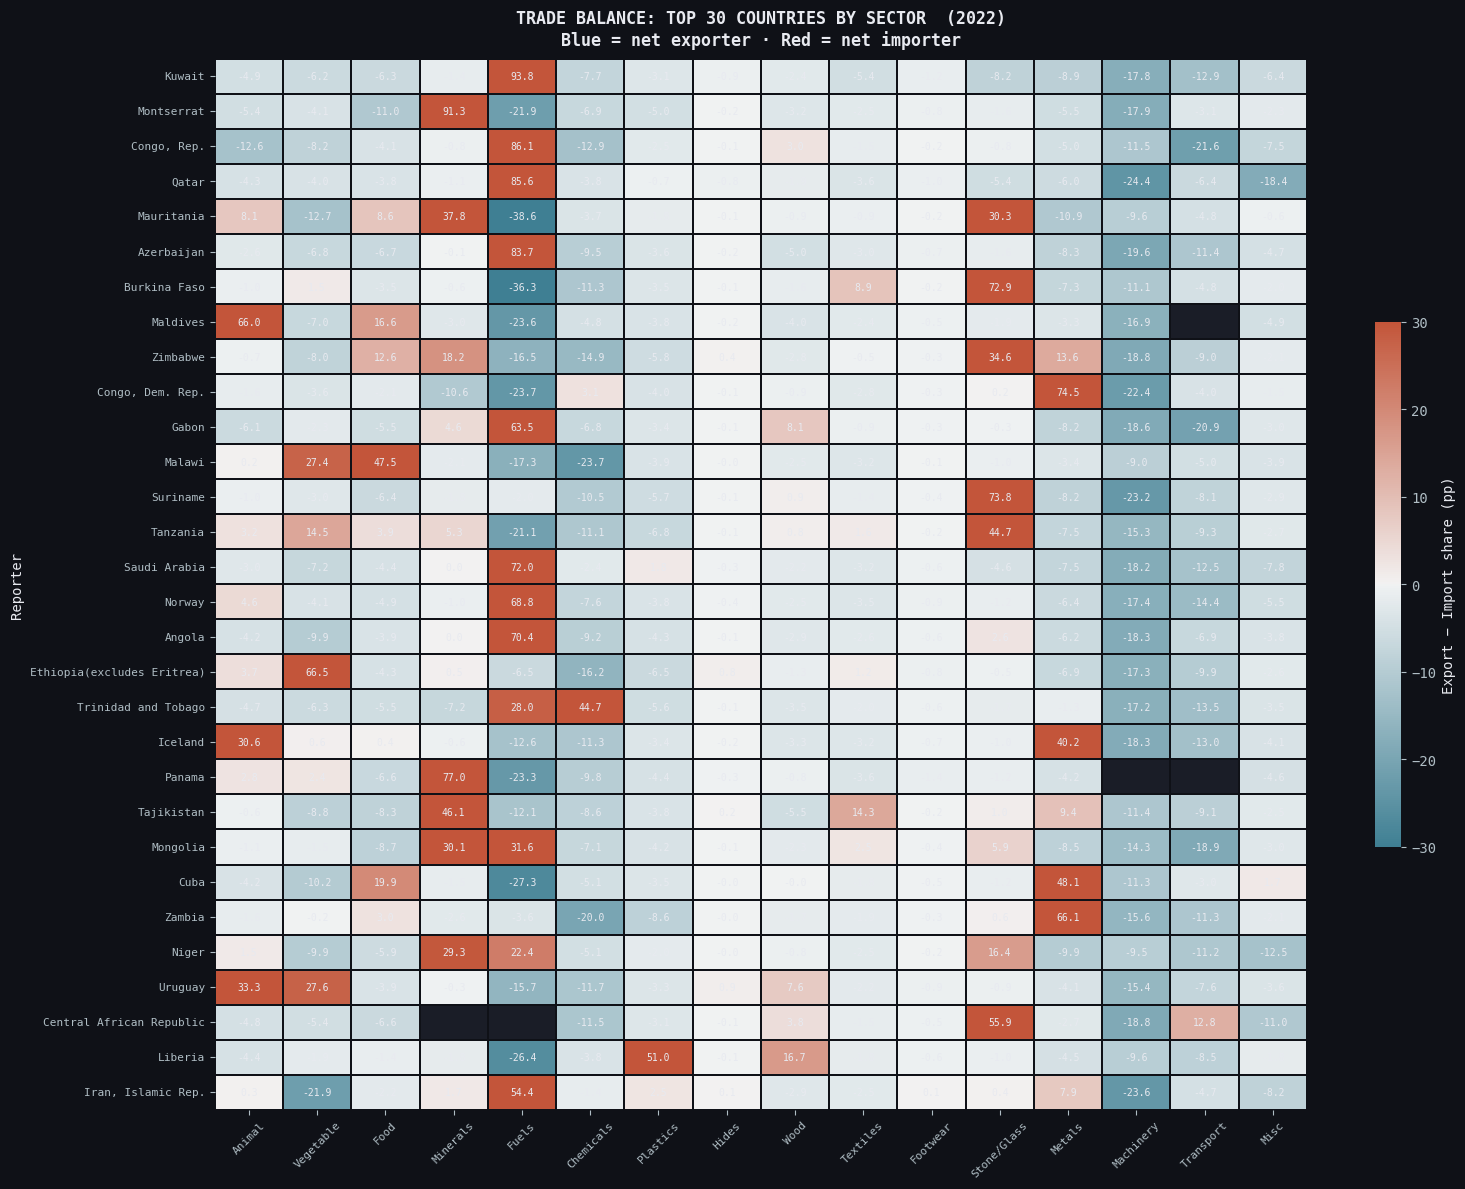

In [12]:
# ── 2B: Country × Sector heatmap (static overview) ────────────────────────
# Show top 30 countries by total trade volume
top_countries = (
    balance_cross.drop(columns='iso3')
    .abs().sum(axis=1)
    .sort_values(ascending=False)
    .head(30).index
)
bal_top = balance_cross.loc[top_countries].drop(columns='iso3').astype(float)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    bal_top,
    ax=ax,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0, vmin=-30, vmax=30,
    linewidths=0.3, linecolor=BACKGROUND,
    annot=True, fmt='.1f', annot_kws={'size': 7, 'color': TEXT},
    cbar_kws={'shrink': 0.5, 'label': 'Export − Import share (pp)'},
)
ax.set_title(
    f'TRADE BALANCE: TOP 30 COUNTRIES BY SECTOR  ({LATEST_YEAR})\n'
    'Blue = net exporter · Red = net importer',
    fontsize=12, fontweight='bold', color=TEXT, pad=10
)
ax.tick_params(axis='x', labelsize=8, rotation=45, colors=ACCENT_NEU)
ax.tick_params(axis='y', labelsize=8, rotation=0, colors=ACCENT_NEU)
plt.tight_layout()
plt.savefig('ch2_country_sector_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

---
## Chapter 3 · Winners & Losers
### Which sectors are growing or shrinking per country over time?

In [13]:
# Load time-series export shares for a set of key countries
# (We do this country-by-country to stay within API limits)
KEY_REPORTERS = {
    'dnk': 'Denmark',
    'usa': 'United States',
    'chn': 'China',
    'deu': 'Germany',
    'gbr': 'United Kingdom',
    'bra': 'Brazil',
    'ind': 'India',
    'zaf': 'South Africa',
}

trend_data = {}  # {country_name: wide DataFrame (year × sector)}

for iso3, name in KEY_REPORTERS.items():
    print(f'\nLoading {name}...')
    raw = load_sector_shares(
        'XPRT-PRDCT-SHR', reporter=iso3, year='all', sector_codes=SECTOR_CODES
    )
    df = extract_series(
        raw, 'Export Product Share (%)', reporter=name, partner='World'
    )
    df.columns = [SECTOR_LABELS.get(c, c) for c in df.columns]
    trend_data[name] = df

print('\nDone.')


Loading Denmark...
  ✓ 01-05_Animal
  ✓ 06-15_Vegetable
  ✓ 16-24_FoodProd
  ✓ 25-26_Minerals
  ✓ 27-27_Fuels
  ✓ 28-38_Chemicals
  ✓ 39-40_PlastiRub
  ✓ 41-43_HidesSkin
  ✓ 44-49_Wood
  ✓ 50-63_TextCloth
  ✓ 64-67_Footwear
  ✓ 68-71_StoneGlas
  ✓ 72-83_Metals
  ✓ 84-85_MachElec
  ✓ 86-89_Transport
  ✓ 90-99_Miscellan

Loading United States...
  ✓ 01-05_Animal
  ✓ 06-15_Vegetable
  ✓ 16-24_FoodProd
  ✓ 25-26_Minerals
  ✓ 27-27_Fuels
  ✓ 28-38_Chemicals
  ✓ 39-40_PlastiRub
  ✓ 41-43_HidesSkin
  ✓ 44-49_Wood
  ✓ 50-63_TextCloth
  ✓ 64-67_Footwear
  ✓ 68-71_StoneGlas
  ✓ 72-83_Metals
  ✓ 84-85_MachElec
  ✓ 86-89_Transport
  ✓ 90-99_Miscellan

Loading China...
  ✓ 01-05_Animal
  ✓ 06-15_Vegetable
  ✓ 16-24_FoodProd
  ✓ 25-26_Minerals
  ✓ 27-27_Fuels
  ✓ 28-38_Chemicals
  ✓ 39-40_PlastiRub
  ✓ 41-43_HidesSkin
  ✓ 44-49_Wood
  ✓ 50-63_TextCloth
  ✓ 64-67_Footwear
  ✓ 68-71_StoneGlas
  ✓ 72-83_Metals
  ✓ 84-85_MachElec
  ✓ 86-89_Transport
  ✓ 90-99_Miscellan

Loading Germany...
  ✓ 01-05_Ani

In [14]:
# ── 3A: Compute linear trend slope per country × sector ───────────────────
def compute_slope(series: pd.Series) -> float:
    """OLS slope of a series against its index (year)."""
    s = series.dropna()
    if len(s) < 5:
        return np.nan
    x = np.array(s.index, dtype=float)
    x = (x - x.mean()) / x.std()  # standardise years
    return np.polyfit(x, s.values, 1)[0]

slope_rows = {}
for country, df in trend_data.items():
    slope_rows[country] = {col: compute_slope(df[col]) for col in df.columns}

slope_df = pd.DataFrame(slope_rows).T   # index=country, columns=sector
slope_df

,Animal,Vegetable,Food Products,Minerals,Fuels,...,Stone and Glass,Metals,Mach and Elec,Transportation,Miscellaneous
Denmark,-2.089856,-0.332784,-0.558788,-0.037189,0.811012,...,-0.128667,0.411749,0.090834,-0.368082,-1.702523
United States,0.064683,0.022708,-0.126850,0.080392,4.141692,...,0.868329,0.157591,-4.903370,-1.487349,1.210109
China,-0.770578,-1.004652,-0.693788,-0.244077,-0.878407,...,0.200151,0.503727,8.650826,0.969750,0.249768
Germany,-0.071551,0.033627,0.325766,-0.012761,0.491247,...,0.084875,-0.427555,-1.093776,0.844587,-0.201655
United Kingdom,-0.012862,-0.048492,-0.054904,-0.031002,0.907013,...,3.443326,-0.329788,-5.098293,0.771581,1.001305
Brazil,1.852716,4.082787,-1.790627,2.246220,4.597080,...,0.198797,-3.575274,-2.164799,-1.278028,-0.651315
India,-0.422952,-1.613231,-0.447463,-0.845132,5.840318,...,-2.269136,1.455960,2.107435,1.933488,-0.171001
South Africa,-0.113667,0.699098,0.015771,4.051332,0.872699,...,3.273429,-1.451164,0.563661,2.226102,-8.557600


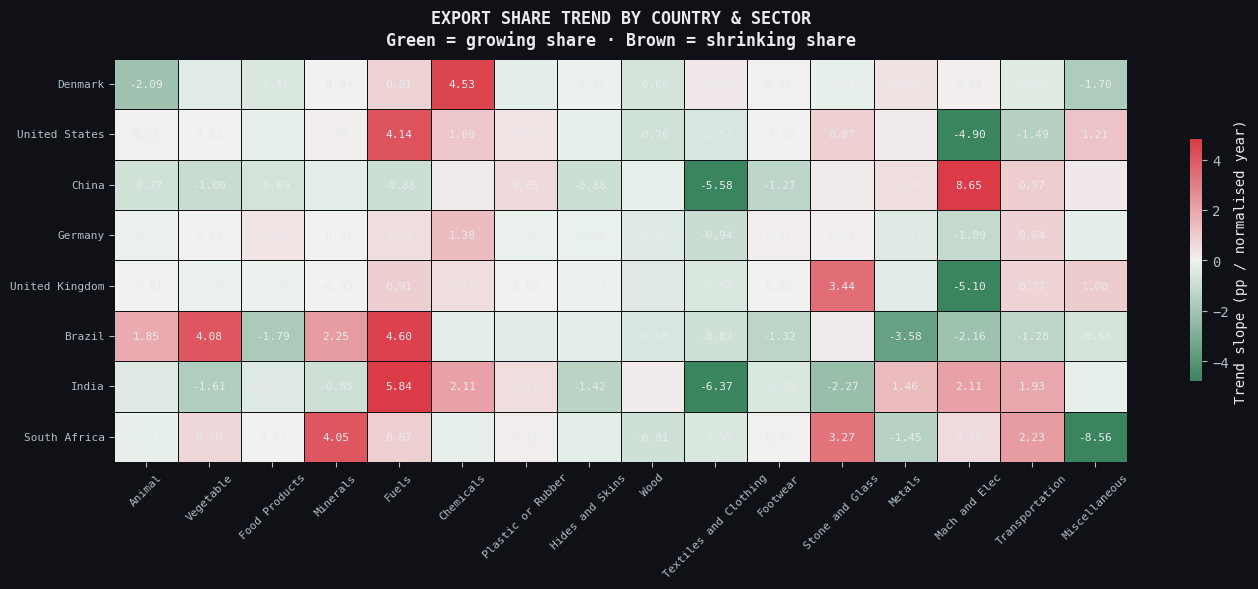

In [15]:
# ── 3B: Trend heatmap — country × sector ──────────────────────────────────
vlim = np.nanpercentile(slope_df.abs().values, 95)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    slope_df,
    ax=ax,
    cmap=sns.diverging_palette(145, 10, as_cmap=True),
    center=0, vmin=-vlim, vmax=vlim,
    linewidths=0.4, linecolor=BACKGROUND,
    annot=True, fmt='.2f', annot_kws={'size': 8, 'color': TEXT},
    cbar_kws={'shrink': 0.6, 'label': 'Trend slope (pp / normalised year)'},
)
ax.set_title(
    'EXPORT SHARE TREND BY COUNTRY & SECTOR\n'
    'Green = growing share · Brown = shrinking share',
    fontsize=12, fontweight='bold', color=TEXT, pad=10
)
ax.tick_params(axis='x', labelsize=8, rotation=45, colors=ACCENT_NEU)
ax.tick_params(axis='y', labelsize=8, rotation=0, colors=ACCENT_NEU)
plt.tight_layout()
plt.savefig('ch3_trend_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

In [16]:
# ── 3C: Plotly line chart — sector share over time, faceted by country ─────
rows_data = []
for country, df in trend_data.items():
    for sector in df.columns:
        for year, val in df[sector].dropna().items():
            rows_data.append({'Country': country, 'Sector': sector,
                               'Year': year, 'Share': val})

long_trend = pd.DataFrame(rows_data)

fig = px.line(
    long_trend,
    x='Year', y='Share', color='Sector',
    facet_col='Country', facet_col_wrap=4,
    title='EXPORT SHARE BY SECTOR OVER TIME',
    labels={'Share': 'Export Share (%)'},
    template='plotly_dark',
    height=700,
)
fig.update_traces(line_width=1.5)
fig.update_layout(font_family='monospace', legend_title='Sector')
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
fig.show()

---
## Chapter 4 · Market Concentration
### Are global product markets getting more or less concentrated over time?
Uses the **Herfindahl-Hirschman Index** (`HH-MKT-CNCNTRTN-NDX`) — higher = more concentrated.

In [36]:
help(wits.get_tariff_reported)


Help on function get_tariff_reported in module world_trade_data.data:

get_tariff_reported(reporter, partner='000', product='all', year='2017', name_or_id='name')
    Tariffs (reported)



In [44]:
df = wits.get_tariff_reported(reporter = "dnk")
print(df.head())
print(df.columns.tolist())

HTTPError: 400 Client Error: Bad Request for url: https://wits.worldbank.org/API/V1/SDMX/V21/rest/data/WITSAPIError/Invalid_Reporter/?format=JSON

In [ ]:
# Check data availability for Denmark tariffs
avail = wits.get_dataavailability(datasource='trn')
print(avail)

TypeError: get_dataavailability() got an unexpected keyword argument 'name'

In [50]:
import pandasdmx as sdmx

wits_sdmx = sdmx.Request('WB')

# List all available dataflows
flows = wits_sdmx.dataflow()
flow_df = sdmx.to_pandas(flows.dataflow)
print(flow_df)


DF_WITS_Tariff_TRAINS             WITS - UNCTAD TRAINS Tariff Data
DF_WITS_TradeStats_Development          WITS TradeStats Devlopment
DF_WITS_TradeStats_Tariff                   WITS TradeStats Tariff
DF_WITS_TradeStats_Trade                     WITS TradeStats Trade
dtype: object


In [54]:
# ── Inspect the dataflow structure ────────────────────────────────────────
flow = wits_sdmx.dataflow('DF_WITS_TradeStats_Tariff')

# Get the data structure definition
dsd = flow.dataflow['DF_WITS_TradeStats_Tariff'].structure
print(sdmx.to_pandas(dsd.dimensions))

['FREQ', 'REPORTER', 'PARTNER', 'PRODUCTCODE', 'INDICATOR', 'YEAR']


In [55]:

ind_codes = sdmx.to_pandas(
    dsd.dimensions.get('INDICATOR').local_representation.enumerated
)
print(ind_codes)

                                                                    name  \
CL_TS_INDICATOR_WITS                                                       
AHS-AVE-TRFF-LN-SHR                       AHS AVE Tariff Lines Share (%)   
AHS-DTBL-MPRT                        AHS Dutiable Imports (US$ Thousand)   
AHS-DTBL-TRFF-LNS-SHR                AHS Dutiable Tariff Lines Share (%)   
AHS-DTY-FR-MPRTs                    AHS Duty Free Imports (US$ Thousand)   
...                                                                  ...   
TX-VAL-OTHR-ZS-WT      Computer, communications and other services (%...   
TX-VAL-SERV-CD-WT               Commercial service exports (current US$)   
TX-VAL-TRAN-ZS-WT      Transport services (% of commercial service ex...   
TX-VAL-TRVL-ZS-WT      Travel services (% of commercial service exports)   

                                     parent  
CL_TS_INDICATOR_WITS                         
AHS-AVE-TRFF-LN-SHR    CL_TS_INDICATOR_WITS  
AHS-DTBL-MPRT          CL

In [56]:
# Filter for tariff-relevant indicators
tariff_indicators = ind_codes[
    ind_codes['name'].str.contains('Tariff|tariff|MFN|AHS|Duty|duty', regex=True)
]
print(tariff_indicators.to_string())


                                                            name                parent
CL_TS_INDICATOR_WITS                                                                  
AHS-AVE-TRFF-LN-SHR               AHS AVE Tariff Lines Share (%)  CL_TS_INDICATOR_WITS
AHS-DTBL-MPRT                AHS Dutiable Imports (US$ Thousand)  CL_TS_INDICATOR_WITS
AHS-DTBL-TRFF-LNS-SHR        AHS Dutiable Tariff Lines Share (%)  CL_TS_INDICATOR_WITS
AHS-DTY-FR-MPRTs            AHS Duty Free Imports (US$ Thousand)  CL_TS_INDICATOR_WITS
AHS-DTY-FR-TRFF-LNS-SHR    AHS Duty Free Tariff  Lines Share (%)  CL_TS_INDICATOR_WITS
AHS-MNMM-RATE                                    AHS MinRate (%)  CL_TS_INDICATOR_WITS
AHS-MXMM-RT                                      AHS MaxRate (%)  CL_TS_INDICATOR_WITS
AHS-SMPL-AVRG                             AHS Simple Average (%)  CL_TS_INDICATOR_WITS
AHS-SPCFC-DTY-MPRT       AHS SpecificDuty Imports (US$ Thousand)  CL_TS_INDICATOR_WITS
AHS-SPCFC-TRFF-LNS-SHR       AHS Specific T

In [60]:
# Pass key as string to skip validation — avoids the extra dataflow fetch
resp = wits_sdmx.data(
    'DF_WITS_TradeStats_Tariff',
    key='A.DNK.WLD.01-05_Animal.MFN-SMPL-AVRG',  # Freq.Reporter.Partner.Product.Indicator
    params={'startperiod': '2010', 'endperiod': '2022'},
)

df = sdmx.to_pandas(resp).reset_index()
print(df.columns.tolist())
print(df.head())

['FREQ', 'REPORTER', 'PARTNER', 'PRODUCTCODE', 'INDICATOR', 'TIME_PERIOD', 'value']
  FREQ REPORTER PARTNER   PRODUCTCODE      INDICATOR TIME_PERIOD      value
0    A      DNK     WLD  01-05_Animal  MFN-SMPL-AVRG        2010  20.124325
1    A      DNK     WLD  01-05_Animal  MFN-SMPL-AVRG        2011  19.673580
2    A      DNK     WLD  01-05_Animal  MFN-SMPL-AVRG        2012  17.106523
3    A      DNK     WLD  01-05_Animal  MFN-SMPL-AVRG        2013  16.535122
4    A      DNK     WLD  01-05_Animal  MFN-SMPL-AVRG        2014  16.584265


In [18]:
# HHI is a per-reporter, all-products indicator — not per-product
# Fetch for each key country, then compare across countries

KEY_REPORTERS_HHI = {
    'dnk': 'Denmark',
    'usa': 'United States', 
    'chn': 'China',
    'deu': 'Germany',
    'gbr': 'United Kingdom',
    'bra': 'Brazil',
    'ind': 'India',
    'zaf': 'South Africa',
    'nor': 'Norway',
    'swe': 'Sweden',
}

hhi_frames = {}
for iso3, name in KEY_REPORTERS_HHI.items():
    try:
        df = wits.get_indicator(
            'HH-MKT-CNCNTRTN-NDX',
            reporter=iso3,
            year='all',
            partner='999',      # ← fixed SDMX value from metadata
            product='999999'    # ← fixed SDMX value from metadata
        )
        print(df)
        flat = df.reset_index()
        mask = (
            (flat['Freq']      == 'Annual') &
            (flat['Partner']   == 'Not Applicable')  &
            (flat['Indicator'] == 'HH Market concentration index')
        )
        s = flat.loc[mask].set_index('Year')['Value']
        s.index = s.index.astype(int)
        hhi_frames[name] = s
        print(f'  ✓ {name}')
    except Exception as e:
        print(f'  ✗ {name}: {e}')

hhi_df = pd.DataFrame(hhi_frames).sort_index()
hhi_df.tail(3)

                                                                                     Value  \
Freq   Reporter Partner        ProductCode    Indicator                     Year             
Annual Denmark  Not Applicable Not Applicable HH Market concentration index 1989  0.264730   
                                                                            1990  0.309230   
                                                                            1991  0.283479   
                                                                            1992  0.180847   
...                                                                                    ...   
                                                                            2020  0.053717   
                                                                            2021  0.055769   
                                                                            2022  0.058187   
                                                            

,Denmark,United States,China,Germany,United Kingdom,Brazil,India,South Africa,Norway,Sweden
Year,,,,,,,,,,
2021,0.055769,0.055716,0.046293,0.038317,0.050744,0.135735,0.054677,0.071126,0.105627,0.044743
2022,0.058187,0.052578,0.043799,0.039354,0.051672,0.106189,0.054480,0.063869,0.109245,0.044222
2023,0.052325,0.053186,0.038245,0.038891,0.050546,0.124275,0.057489,0.068338,0.085493,0.043319


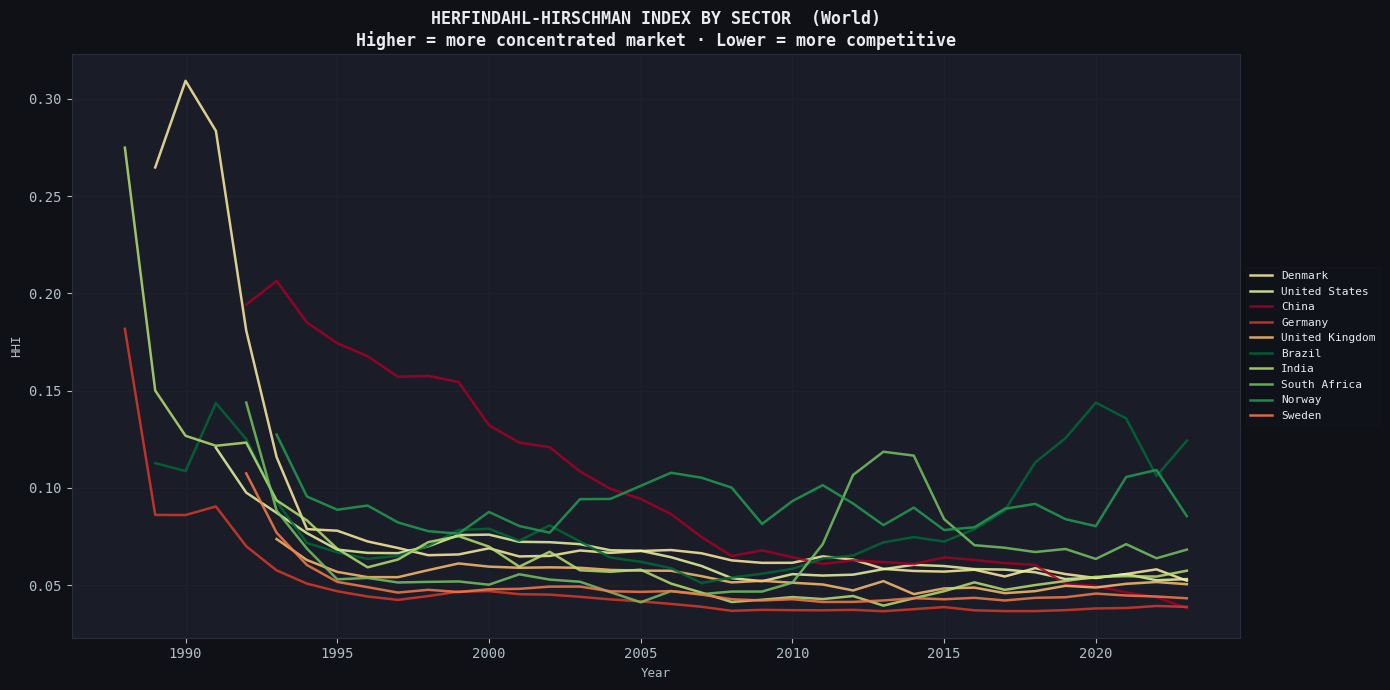

Most concentrated sectors (2023):
Brazil           0.124275
Norway           0.085493
South Africa     0.068338
India            0.057489
United States    0.053186


In [19]:
# ── 4A: HHI over time — lines coloured by current concentration ───────────
latest_hhi = hhi_df.iloc[-1].sort_values(ascending=False)
cmap_hhi = plt.cm.get_cmap('RdYlGn_r', len(hhi_df.columns))
color_map = {sec: cmap_hhi(i) for i, sec in enumerate(latest_hhi.index)}

fig, ax = plt.subplots(figsize=(14, 7))
for sector in hhi_df.columns:
    s = hhi_df[sector].dropna()
    ax.plot(s.index, s.values, label=sector,
            color=color_map[sector], linewidth=1.8, alpha=0.85)

ax.set_title(
    'HERFINDAHL-HIRSCHMAN INDEX BY SECTOR  (World)\n'
    'Higher = more concentrated market · Lower = more competitive',
    fontsize=12, fontweight='bold', color=TEXT
)
ax.set_xlabel('Year', fontsize=9, color=ACCENT_NEU)
ax.set_ylabel('HHI', fontsize=9, color=ACCENT_NEU)
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=8, framealpha=0.15)
plt.tight_layout()
plt.savefig('ch4_hhi.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

print(f'Most concentrated sectors ({hhi_df.index[-1]}):')
print(latest_hhi.head(5).to_string())

---
## Chapter 5 · Denmark in Context
### How does Denmark compare to the world — and to similar economies?

In [20]:
# Load Denmark time series (re-use if already loaded in KEY_REPORTERS above)
dnk_df = trend_data.get('Denmark')

if dnk_df is None:
    print('Loading Denmark export shares...')
    dnk_raw = load_sector_shares(
        'XPRT-PRDCT-SHR', reporter='dnk', year='all', sector_codes=SECTOR_CODES
    )
    dnk_df = extract_series(
        dnk_raw, 'Export Product Share (%)', reporter='Denmark', partner='World'
    )
    dnk_df.columns = [SECTOR_LABELS.get(c, c) for c in dnk_df.columns]

print('Denmark data ready.')
dnk_df.tail(3)

Denmark data ready.


,Animal,Vegetable,Food Products,Minerals,Fuels,...,Stone and Glass,Metals,Mach and Elec,Transportation,Miscellaneous
Year,,,,,,,,,,,
2021,9.6894,2.9833,6.1557,0.2331,4.8395,...,1.1041,6.4301,21.0792,4.1118,8.8027
2022,9.4439,2.9922,5.8876,0.2131,7.3320,...,1.0638,6.2460,19.2819,4.3176,8.8044
2023,9.9842,3.1365,6.3090,0.2266,4.6787,...,0.9482,6.2594,19.4142,5.2436,8.6340


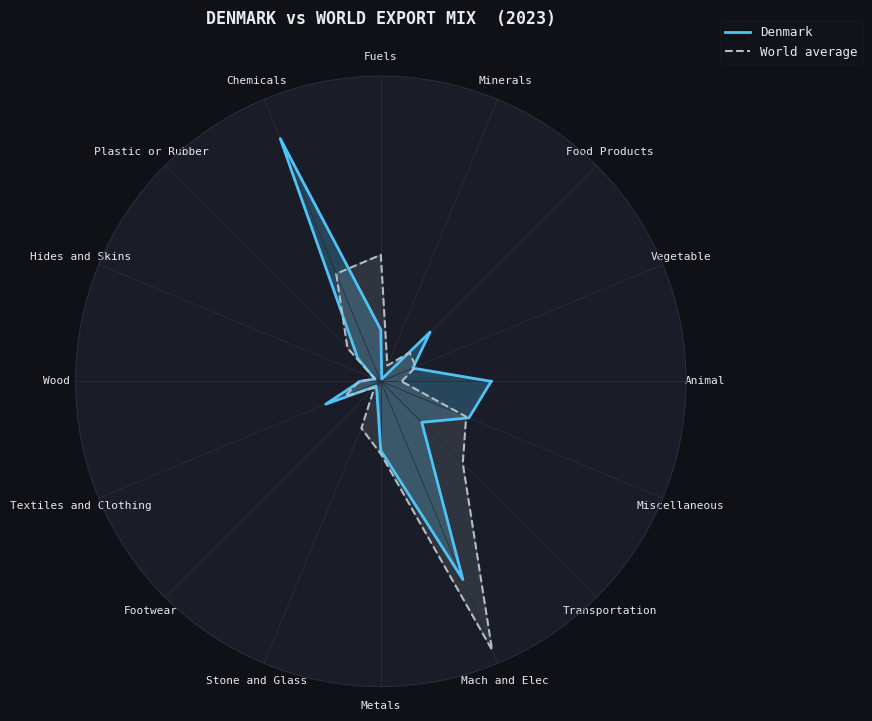

In [21]:
# ── 5A: Radar / spider chart — Denmark vs World (latest year) ─────────────
common_year = max(
    dnk_df.dropna(how='all').index[-1],
    wld_export_df.dropna(how='all').index[-1]
)

dnk_latest = dnk_df.loc[common_year].fillna(0)
wld_latest = wld_export_df.loc[common_year].reindex(dnk_latest.index).fillna(0)

sectors_r = dnk_latest.index.tolist()
N = len(sectors_r)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

dnk_vals = dnk_latest.tolist() + [dnk_latest.iloc[0]]
wld_vals = wld_latest.tolist() + [wld_latest.iloc[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor(PANEL)
fig.patch.set_facecolor(BACKGROUND)

ax.fill(angles, dnk_vals, color=ACCENT_EXP, alpha=0.25)
ax.plot(angles, dnk_vals, color=ACCENT_EXP, linewidth=2, label='Denmark')
ax.fill(angles, wld_vals, color=ACCENT_NEU, alpha=0.15)
ax.plot(angles, wld_vals, color=ACCENT_NEU, linewidth=1.5,
        linestyle='--', label='World average')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(sectors_r, fontsize=8, color=TEXT)
ax.set_yticks([])
ax.grid(color=GRID, linewidth=0.6)
ax.spines['polar'].set_color(GRID)
ax.set_title(f'DENMARK vs WORLD EXPORT MIX  ({common_year})',
             fontsize=12, fontweight='bold', color=TEXT, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1),
          fontsize=9, framealpha=0.2)

plt.tight_layout()
plt.savefig('ch5_radar.png', dpi=150, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

In [67]:
# ── 5A: Interactive radar — pure Plotly, no ipywidgets ────────────────────
import plotly.graph_objects as go

# Rebuild country_lookup from trend_data
sectors_r = wld_export_df.columns.tolist()
world_latest = wld_export_df.dropna(how='all').iloc[-1].fillna(0)

country_lookup = {}
for country, df in trend_data.items():
    latest = df.dropna(how='all').iloc[-1].fillna(0)
    latest = latest.reindex(wld_export_df.columns).fillna(0)
    country_lookup[country] = latest

country_lookup['World (avg)'] = world_latest

print(f'Countries available: {sorted(country_lookup.keys())}')


sectors_closed = sectors_r + [sectors_r[0]]

fig = go.Figure()

# Add one trace per country — all hidden by default
for country, series in country_lookup.items():
    vals = series.tolist() + [series.iloc[0]]
    visible = country in ('Denmark', 'World (avg)')  # default visible pair
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=sectors_closed,
        fill='toself', name=country,
        visible=visible,
        line=dict(width=2),
    ))

countries_sorted = list(country_lookup.keys())

def make_button(label, visible_set):
    """Button that shows only the countries in visible_set."""
    return dict(
        label=label,
        method='update',
        args=[{'visible': [c in visible_set for c in countries_sorted]}],
    )

# One button per country for dropdown A, fixed World (avg) always on
buttons_a = [make_button(c, {c, 'World (avg)'}) for c in countries_sorted]
buttons_b = [make_button(c, {'Denmark', c})     for c in countries_sorted]

fig.update_layout(

    
    updatemenus=[
        dict(
            buttons=buttons_a,
            direction='down',
            x=0.01, y=1.15, xanchor='left',
            showactive=True,
            bgcolor=PANEL, bordercolor=GRID,
            font=dict(color=TEXT, size=10),
        ),
        dict(
            buttons=buttons_b,
            direction='down',
            x=0.25, y=1.15, xanchor='left',
            showactive=True,
            bgcolor=PANEL, bordercolor=GRID,
            font=dict(color=TEXT, size=10),
        ),
        
    ],
    
    annotations=[
        dict(text='Country A', x=0.01, y=1.20, xref='paper', yref='paper',
             showarrow=False, font=dict(color=TEXT, size=11)),
        dict(text='Country B', x=0.25, y=1.20, xref='paper', yref='paper',
             showarrow=False, font=dict(color=TEXT, size=11)),
    ],
    polar=dict(
        bgcolor=PANEL,
        radialaxis=dict(visible=True, color=ACCENT_NEU, gridcolor=GRID),
        angularaxis=dict(color=TEXT, gridcolor=GRID),
    ),
    paper_bgcolor=BACKGROUND,
    font=dict(color=TEXT, family='monospace'),
    title=dict(text='EXPORT MIX COMPARISON — select countries above',
               font=dict(size=13, color=TEXT),
                y=0.97,
                x=0.5,
                xanchor="center",
    ),
    margin=dict(t=150),

    legend=dict(bgcolor=PANEL, bordercolor=GRID),
    width=900, height=700,
    template='plotly_dark',
)
fig.show()

Countries available: ['Brazil', 'China', 'Denmark', 'Germany', 'India', 'South Africa', 'United Kingdom', 'United States', 'World (avg)']


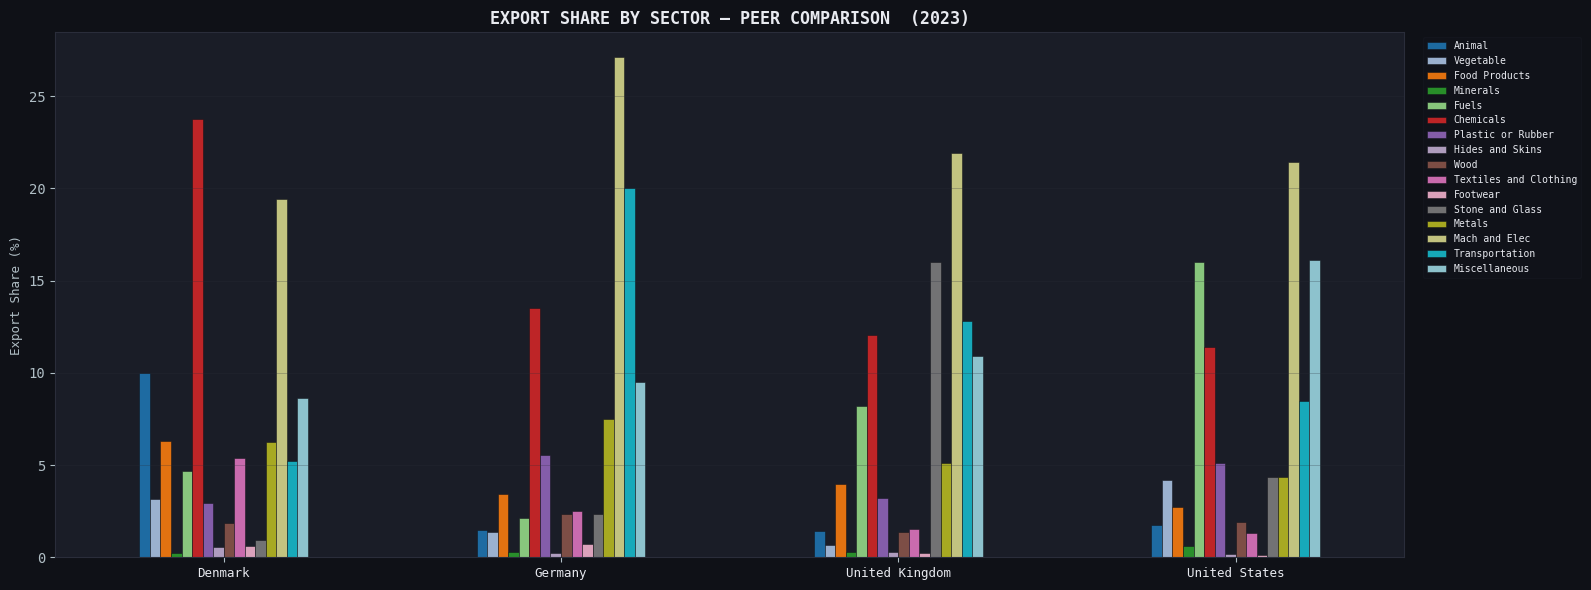

In [ ]:
# ── 5B: Denmark vs peer countries — grouped bar ────────────────────────────
peers = ['Denmark', 'Germany', 'United Kingdom', 'United States']
peer_latest = {
    c: trend_data[c].loc[common_year].fillna(0)
    for c in peers if c in trend_data
}
peer_df = pd.DataFrame(peer_latest).T   # index=country, columns=sector

peer_df.plot(
    kind='bar',
    figsize=(16, 6),
    colormap='tab20',
    edgecolor=BACKGROUND,
    linewidth=0.4,
    alpha=0.88,
)
plt.title(f'EXPORT SHARE BY SECTOR — PEER COMPARISON  ({common_year})',
          fontsize=12, fontweight='bold', color=TEXT)
plt.xlabel('')
plt.ylabel('Export Share (%)', fontsize=9, color=ACCENT_NEU)
plt.xticks(rotation=0, fontsize=9, color=TEXT)
plt.legend(bbox_to_anchor=(1.01, 1), fontsize=7, framealpha=0.15)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ch5_peer_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

---
## Data Story · Key Insights

Use this cell to write up the narrative after running all analyses above.
Fill in the `[ ]` placeholders with actual findings from your charts.

---

### 🌍 The Big Picture
Global trade is dominated by **Machinery & Electronics** and **Fuels**, which together account for roughly [ ]% of world exports. The stacked area chart reveals that **Machinery** has [ grown / declined ] steadily since the 1990s, while **Fuels** show clear volatility tied to oil price cycles.

### 🔗 Sector Correlations
The correlation matrix shows that **[ sector A ]** and **[ sector B ]** are strongly negatively correlated (r ≈ [ ]), suggesting they compete for the same trade share — when one rises, the other falls. Conversely, **[ sector C ]** and **[ sector D ]** move together, likely driven by shared demand cycles.

### 🗺️ Who Trades What
The geo heatmap reveals sharp regional specialisations. **Fuels** shows the starkest pattern — Gulf states and Russia dominate exports while Europe and East Asia are overwhelmingly net importers. For **Machinery**, the pattern reverses: Germany, Japan, and China are deep-blue net exporters.

### 📈 Winners & Losers
Over the full time series, **China** shows the steepest rising trend in **Machinery** exports (+[ ] pp / decade), while simultaneously shedding share in **Textiles** as wages rose. **Denmark** has [ maintained / grown / lost ] its position in **Food & Animal** products, consistent with its agricultural identity.

### 📊 Market Concentration
The HHI analysis shows **Fuels** remains the most concentrated market (dominated by a few large exporters), while **Food** and **Textiles** are among the most competitive. Notably, concentration in **Machinery** has [ increased / decreased ] since [ year ], reflecting [ China's rise / supply chain shifts ].

### 🇩🇰 Denmark in Context
The radar chart shows Denmark exports a disproportionately large share in **Animal & Food** products compared to both the world average and its European peers. Its **Machinery** share is [ above / below ] the EU average, suggesting [ interpretation ]. Compared to Germany, Denmark is more commodity-oriented and less machinery-intensive.

In [ ]:
# ── Summary table: Denmark sector shares vs World, with trend ──────────────
summary = pd.DataFrame({
    'Denmark share %':  dnk_df.iloc[-1].round(2),
    'World share %':    wld_export_df.reindex(columns=dnk_df.columns).iloc[-1].round(2),
    'DNK trend (slope)': slope_df.loc['Denmark'].round(3),
})
summary['DNK vs World (pp)'] = (summary['Denmark share %'] - summary['World share %']).round(2)
summary = summary.sort_values('DNK vs World (pp)', ascending=False)

print(f'Denmark export profile vs World ({dnk_df.index[-1]}):')
summary

Denmark export profile vs World (2023):


,Denmark share %,World share %,DNK trend (slope),DNK vs World (pp)
Chemicals,23.79,10.54,4.526,13.25
Animal,9.98,1.88,-2.090,8.10
Food Products,6.31,3.68,-0.559,2.63
Textiles and Clothing,5.40,3.49,0.262,1.91
...,...,...,...,...
Stone and Glass,0.95,4.59,-0.129,-3.64
Transportation,5.24,10.49,-0.368,-5.25
Fuels,4.68,11.45,0.811,-6.77
Mach and Elec,19.41,26.32,0.091,-6.91
